# Road-Level AQI Estimation for Mumbai
## Stage 1: Data Cleaning & Preprocessing

**Dataset:** Merged hourly pollutant readings from 27 AQI monitoring stations across Mumbai  
**Pollutants:** PM2.5 (24h avg), PM10 (24h avg), NO₂ (1h), CO (8h), SO₂ (1h)  
**Meteorological:** Temperature, Relative Humidity, Wind Speed, Wind Direction  

**AQI Calculation Note:** Indian AQI is computed as the **maximum sub-index** across all available pollutants per observation, using CPCB breakpoint tables.

---

## 0. Imports & Setup

In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Load Data

In [312]:
RAW_PATH = 'merged_station_data.csv'

df = pd.read_csv(
    RAW_PATH,
    parse_dates=['datetime'],
    low_memory=False
)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"\nColumns: {list(df.columns)}")

Shape: 118,924 rows × 15 columns
Date range: 2025-07-01 00:00:00 → 2025-12-31 23:00:00

Columns: ['datetime', 'location_id', 'location', 'lat', 'lon', 'pm25_24h', 'pm10_24h', 'no2_1h', 'co_8h', 'temperature', 'relativehumidity', 'wind_speed', 'wind_direction', 'source_file', 'so2_1h']


In [313]:
df.head(3)

,datetime,location_id,location,lat,lon,pm25_24h,pm10_24h,no2_1h,co_8h,temperature,relativehumidity,wind_speed,wind_direction,source_file,so2_1h
0,2025-07-01 00:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,7.1600,60.9100,14.8300,0.4700,0.0000,0.0000,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
1,2025-07-01 01:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,6.4750,58.9663,13.4425,0.5012,0.0000,0.0000,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
2,2025-07-01 02:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,8.1550,60.6550,12.4500,0.4875,0.0000,0.0000,NaN,NaN,11606_pivoted_hourly.xlsx,NaN


In [314]:
df.dtypes

datetime            datetime64[us]
location_id                float64
location                       str
lat                        float64
lon                        float64
pm25_24h                   float64
pm10_24h                   float64
no2_1h                     float64
co_8h                      float64
temperature                float64
relativehumidity           float64
wind_speed                 float64
wind_direction             float64
source_file                    str
so2_1h                     float64
dtype: object

## 2. Column Definitions & Renaming

Standardise column names for clarity throughout the project.

In [315]:
# Rename for consistency
RENAME_MAP = {
    'datetime':          'datetime',
    'location_id':       'station_id',
    'location':          'station_name',
    'lat':               'lat',
    'lon':               'lon',
    'pm25_24h':          'pm25',       # µg/m³ — 24-hour average
    'pm10_24h':          'pm10',       # µg/m³ — 24-hour average
    'no2_1h':            'no2',        # µg/m³ — 1-hour
    'co_8h':             'co',         # mg/m³ — 8-hour
    'so2_1h':            'so2',        # µg/m³ — 1-hour
    'temperature':       'temp',       # °C
    'relativehumidity':  'rh',         # %
    'wind_speed':        'ws',         # m/s
    'wind_direction':    'wd',         # degrees
    'source_file':       'source_file'
}

df.rename(columns=RENAME_MAP, inplace=True)

# Column groups for later use
POLLUTANT_COLS = ['pm25', 'pm10', 'no2', 'co', 'so2']
MET_COLS       = ['temp', 'rh', 'ws', 'wd']
ID_COLS        = ['datetime','station_id', 'station_name', 'lat', 'lon']

print("Renamed columns:", list(df.columns))

Renamed columns: ['datetime', 'station_id', 'station_name', 'lat', 'lon', 'pm25', 'pm10', 'no2', 'co', 'temp', 'rh', 'ws', 'wd', 'source_file', 'so2']


## 3. Basic Structure Audit

In [316]:
# Unique stations
stations = df[['station_id','station_name','lat','lon']].drop_duplicates().reset_index(drop=True)
print(f"Unique stations: {stations['station_id'].nunique()}")
stations

Unique stations: 27


,station_id,station_name,lat,lon
0,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689
1,NaN,NaN,NaN,NaN
2,11611.0000,"Malad West, Mumbai - IITM-3379673",19.1971,72.8220
3,12024.0000,"Chakala-Andheri East, Mumbai - IITM-3379671",19.1107,72.8608
4,12039.0000,"Khindipada-Bhandup West, Mumbai - IITM-3379669",19.1644,72.9283
5,12040.0000,"Mulund West, Mumbai - MPCB-3379680",19.1750,72.9419
6,12044.0000,"Kandivali East, Mumbai - MPCB-3379679",19.2058,72.8682
7,3409323.0000,"Worli, Mumbai - MPCB-3379612",18.9936,72.8128
8,3409328.0000,"Bandra Kurla Complex, Mumbai - IITM-3961029",19.0627,72.8461
9,3409329.0000,"Deonar, Mumbai - IITM-3379668",19.0495,72.9230


In [317]:
# Records per station
rps = df.groupby('station_name').size().rename('record_count').sort_values(ascending=False)
print("Records per station:")
print(rps.to_string())

Records per station:
station_name
Malad West, Mumbai - IITM-3379673                                4233
Mindspace-Malad West, Mumbai - MPCB-3379895                      4211
Kherwadi_Bandra East, Mumbai - MPCB-3379902                      4188
Deonar, Mumbai - IITM-3379668                                    4187
Chakala-Andheri East, Mumbai - IITM-3379671                      4149
Bandra Kurla Complex, Mumbai - MPCB-3379898                      4100
Borivali East, Mumbai - IITM-3379672                             4062
Shivaji Nagar, Mumbai - BMC-3379921                              4047
Siddharth Nagar-Worli, Mumbai - IITM-3379674                     4022
Khindipada-Bhandup West, Mumbai - IITM-3379669                   4003
Bhayandar West, Mira-Bhayandar - MPCB-3379894                    3983
Chembur, Mumbai - MPCB-3379899                                   3973
Ghatkopar, Mumbai - BMC-3379924                                  3966
Byculla, Mumbai - BMC-3379920                           

## 4. Duplicate Detection & Removal

In [318]:
# Exact duplicate rows
n_exact = df.duplicated().sum()
print(f"Exact duplicate rows: {n_exact}")

# Logical duplicates: same station + same timestamp
n_logical = df.duplicated(subset=['datetime', 'station_id']).sum()
print(f"Logical duplicates (same station+time): {n_logical}")

# Drop rows where station_id is null — these are orphaned readings with no station identity
n_null_station = df['station_id'].isnull().sum()
print(f"Rows with null station_id (dropped)  : {n_null_station}")
df = df.dropna(subset=['station_id'])

# Keep first occurrence of any remaining duplicates
df.drop_duplicates(subset=['datetime', 'station_id'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nShape after deduplication: {df.shape}")

Exact duplicate rows: 0
Logical duplicates (same station+time): 14150
Rows with null station_id (dropped)  : 18460

Shape after deduplication: (100464, 15)


## 5. Missing Value Analysis

### 5a. Overall Missing Values

In [319]:
total = len(df)
missing = df.isnull().sum()
missing_pct = (missing / total * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Present Count': total - missing,
    'dtype': df.dtypes
}).sort_values('Missing %', ascending=False)

print(f"Total rows: {total:,}")
missing_df

Total rows: 100,464


,Missing Count,Missing %,Present Count,dtype
wd,66213,65.9100,34251,float64
ws,66183,65.8800,34281,float64
rh,20225,20.1300,80239,float64
temp,20199,20.1100,80265,float64
so2,16272,16.2000,84192,float64
co,6224,6.2000,94240,float64
pm25,4125,4.1100,96339,float64
no2,2168,2.1600,98296,float64
pm10,285,0.2800,100179,float64
lat,0,0.0000,100464,float64


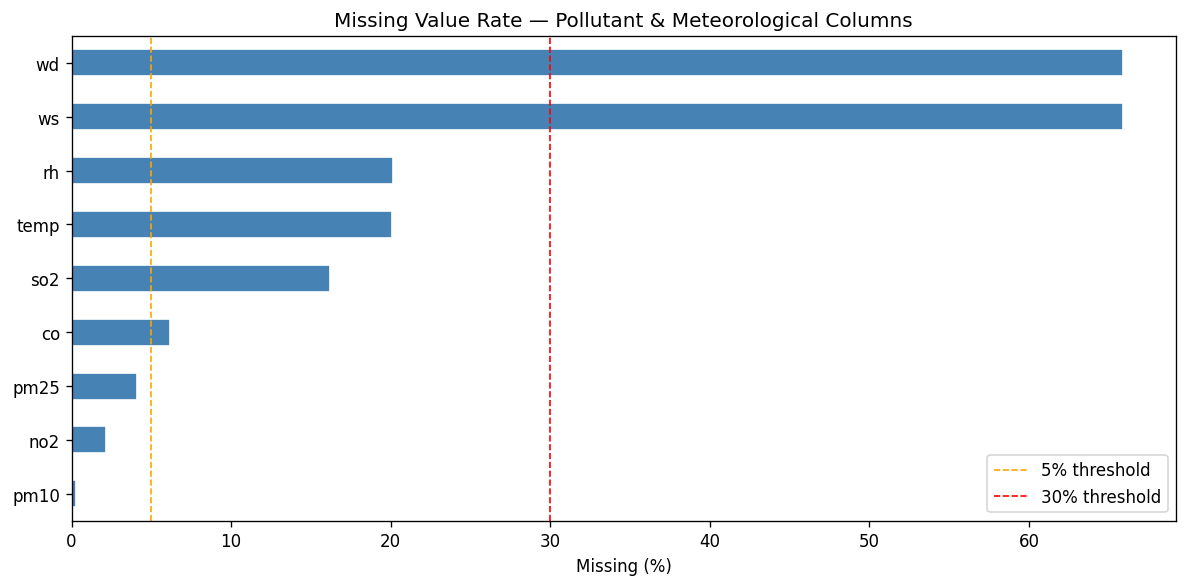

In [320]:
# Visualise missing %
fig, ax = plt.subplots(figsize=(10, 5))
cols_to_plot = POLLUTANT_COLS + MET_COLS
missing_pct[cols_to_plot].sort_values(ascending=True).plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Value Rate — Pollutant & Meteorological Columns')
ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='5% threshold')
ax.axvline(30, color='red', linestyle='--', linewidth=1, label='30% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 5b. Missing Values Per Station

In [321]:
station_missing = (
    df.groupby('station_name')[POLLUTANT_COLS + MET_COLS]
    .apply(lambda g: (g.isnull().mean() * 100).round(2))
)
print("Missing % per station per column:")
station_missing

Missing % per station per column:


,pm25,pm10,no2,co,so2,temp,rh,ws,wd
station_name,,,,,,,,,
"Bandra Kurla Complex, Mumbai - IITM-3961029",0.0000,0.0000,3.9100,0.3900,0.2300,95.3800,95.3800,97.9800,97.9800
"Bandra Kurla Complex, Mumbai - MPCB-3379898",0.0000,0.0000,0.4900,0.0000,0.5100,0.3700,0.3900,53.1500,53.1500
"Bhayandar West, Mira-Bhayandar - MPCB-3379894",0.0000,0.0000,0.0500,0.0000,0.1300,0.0000,0.0000,57.9000,57.9000
"Borivali East, Mumbai - IITM-3379672",0.0000,0.0000,2.1700,0.0000,100.0000,63.7600,63.7600,99.6100,99.6100
"Borivali East, Mumbai - MPCB-3397958",0.0000,0.1500,0.2800,0.7400,0.8300,85.8800,85.9100,85.8800,85.8800
"Byculla, Mumbai - BMC-3379920",0.0000,0.0000,4.8600,1.5800,3.5100,2.6400,2.8000,57.0300,57.3100
"Chakala-Andheri East, Mumbai - IITM-3379671",0.0000,0.0000,1.5400,0.0000,0.0000,0.0000,0.0000,53.0500,53.0500
"Chembur, Mumbai - MPCB-3379899",0.0000,0.0000,0.2000,0.0800,0.2000,0.2300,0.2300,53.0600,53.0600
"Chhatrapati Shivaji Intl. Airport (T2), Mumbai - MPCB-3379606",0.0000,0.0000,0.6400,4.2600,0.1100,0.7300,0.7300,63.3100,63.3100


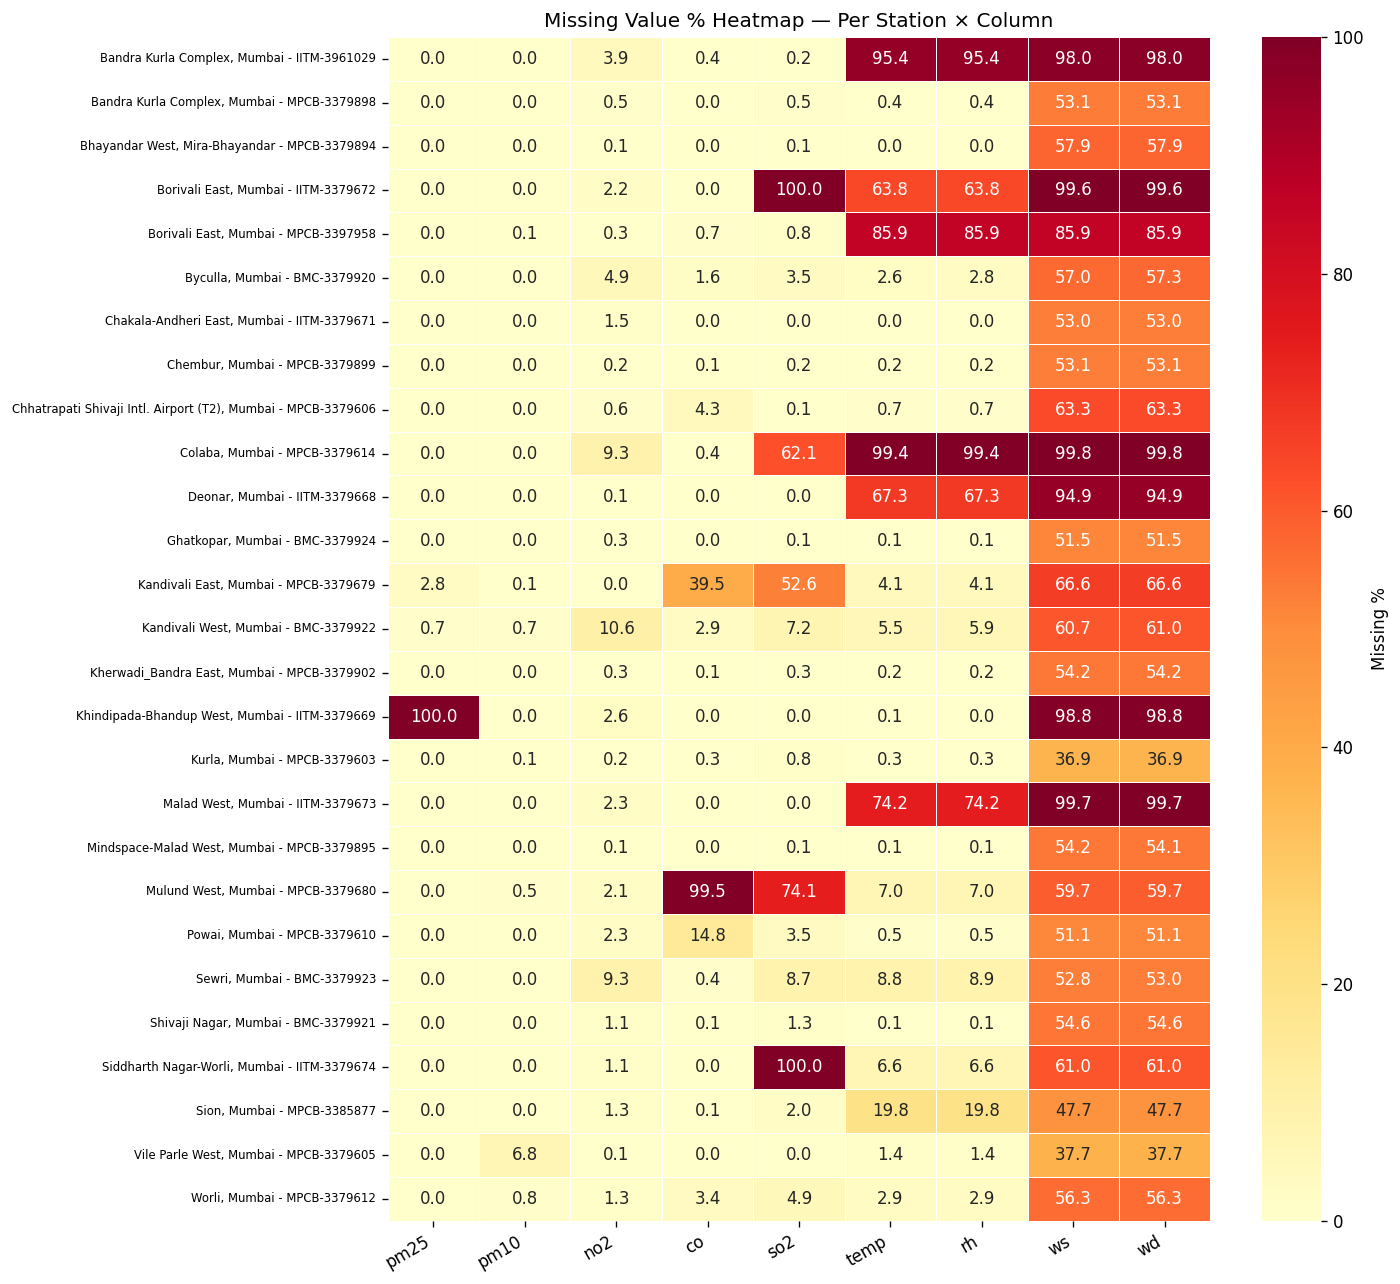

In [322]:
# Heatmap of missing values by station
fig, ax = plt.subplots(figsize=(12, max(6, len(station_missing)*0.4)))
sns.heatmap(
    station_missing,
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Missing %'}
)
ax.set_title('Missing Value % Heatmap — Per Station × Column')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [323]:
df.head()

,datetime,station_id,station_name,lat,lon,pm25,pm10,no2,co,temp,rh,ws,wd,source_file,so2
0,2025-07-01 00:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,7.1600,60.9100,14.8300,0.4700,0.0000,0.0000,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
1,2025-07-01 01:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,6.4750,58.9663,13.4425,0.5012,0.0000,0.0000,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
2,2025-07-01 02:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,8.1550,60.6550,12.4500,0.4875,0.0000,0.0000,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
3,2025-07-01 03:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,9.3131,59.3944,11.2200,0.5037,0.0000,0.0000,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
4,2025-07-01 04:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,9.6845,58.1755,12.6800,0.5175,0.0000,0.0000,NaN,NaN,11606_pivoted_hourly.xlsx,NaN


### 5c. Consecutive Gap Analysis (Temporal Continuity)

In [324]:
def max_consecutive_missing(series):
    """Return the maximum run of consecutive NaN values."""
    is_null = series.isnull()
    max_run = 0
    run = 0
    for v in is_null:
        if v:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

gap_df = {}
for stn, grp in df.groupby('station_name'):
    grp_sorted = grp.sort_values('datetime')
    gap_df[stn] = {
        col: max_consecutive_missing(grp_sorted[col])
        for col in POLLUTANT_COLS + MET_COLS
    }

gap_df = pd.DataFrame(gap_df).T
print("Max consecutive missing hours per station per column:")
gap_df

Max consecutive missing hours per station per column:


,pm25,pm10,no2,co,so2,temp,rh,ws,wd
"Bandra Kurla Complex, Mumbai - IITM-3961029",0,0,47,8,2,981,981,2094,2094
"Bandra Kurla Complex, Mumbai - MPCB-3379898",0,0,3,0,3,3,3,2165,2165
"Bhayandar West, Mira-Bhayandar - MPCB-3379894",0,0,1,0,4,0,0,2306,2306
"Borivali East, Mumbai - IITM-3379672",0,0,24,0,4062,478,478,2334,2334
"Borivali East, Mumbai - MPCB-3397958",0,4,1,18,3,2785,2785,2785,2785
"Byculla, Mumbai - BMC-3379920",0,0,27,11,18,14,14,2157,2157
"Chakala-Andheri East, Mumbai - IITM-3379671",0,0,17,0,0,0,0,2201,2201
"Chembur, Mumbai - MPCB-3379899",0,0,2,1,2,2,2,2101,2101
"Chhatrapati Shivaji Intl. Airport (T2), Mumbai - MPCB-3379606",0,0,7,152,1,7,7,2254,2254
"Colaba, Mumbai - MPCB-3379614",0,0,278,9,17,895,895,2240,2240


## 6. Sensor Validity Checks — Zero & Negative Values

Zeros in pollutant columns can indicate sensor malfunction or calibration drift. Values of exactly 0.0 across temperature/humidity can similarly be sentinel errors.

In [325]:
zero_summary = {}
for col in POLLUTANT_COLS + MET_COLS:
    n_zero = (df[col] == 0).sum()
    n_neg  = (df[col] < 0).sum()
    zero_summary[col] = {
        'zero_count': n_zero,
        'zero_%': round(n_zero / total * 100, 2),
        'negative_count': n_neg,
        'negative_%': round(n_neg / total * 100, 2)
    }

zero_df = pd.DataFrame(zero_summary).T
print("Zero & Negative value audit:")
zero_df

Zero & Negative value audit:


,zero_count,zero_%,negative_count,negative_%
pm25,189.0000,0.1900,0.0000,0.0000
pm10,178.0000,0.1800,48.0000,0.0500
no2,2114.0000,2.1000,8.0000,0.0100
co,1348.0000,1.3400,353.0000,0.3500
so2,1819.0000,1.8100,130.0000,0.1300
temp,4775.0000,4.7500,122.0000,0.1200
rh,4869.0000,4.8500,77.0000,0.0800
ws,3992.0000,3.9700,57.0000,0.0600
wd,2036.0000,2.0300,19.0000,0.0200


In [326]:
# Flag zero temperature & humidity as likely sensor errors
# (Mumbai never has 0°C or 0% RH)
df.loc[df['temp'] == 0.0, 'temp'] = np.nan
df.loc[df['rh']   == 0.0, 'rh']   = np.nan

# Negative pollutant readings are physically impossible
for col in POLLUTANT_COLS:
    n_neg = (df[col] < 0).sum()
    if n_neg > 0:
        print(f"  Setting {n_neg} negative values in '{col}' → NaN")
        df.loc[df[col] < 0, col] = np.nan

print("Zero/negative cleaning done.")

  Setting 48 negative values in 'pm10' → NaN
  Setting 8 negative values in 'no2' → NaN
  Setting 353 negative values in 'co' → NaN
  Setting 130 negative values in 'so2' → NaN
Zero/negative cleaning done.


## 7. Descriptive Statistics

In [327]:
df[POLLUTANT_COLS + MET_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
pm25,96339.0000,73.9361,624.9183,0.0000,3.1734,7.1298,14.5727,23.1512,53.6874,121.8687,985.0000,30258.8189
pm10,100131.0000,186.5918,2446.4665,0.0000,10.1544,21.3992,40.6650,65.1384,123.2628,267.2131,1389.0000,169942.1281
no2,98288.0000,25.0817,455.1737,0.0000,0.0000,2.0225,7.0046,13.8329,26.6954,66.0041,109.6648,99999.0100
co,93887.0000,0.5857,2.0414,0.0000,0.0000,0.0590,0.2625,0.4387,0.6848,1.3366,2.1632,99.9990
so2,84062.0000,29.6680,1250.9901,0.0000,0.0000,0.4875,2.6000,5.5850,13.9846,29.2667,50.2500,99999.0100
temp,75490.0000,27.7992,12.6520,-192.2700,1.1900,21.1375,25.1700,27.5150,29.6900,37.4078,58.9000,2070.8200
rh,75370.0000,72.8893,48.2385,-30.0000,11.5769,22.1673,54.8473,77.6142,87.4825,99.9000,99.9100,4187.7000
ws,34281.0000,2.7513,7.6111,-33.6800,0.0000,0.0000,0.4350,0.9000,1.6950,14.1550,43.8127,154.9900
wd,34251.0000,168.1997,268.5583,-1.5400,0.0000,0.0000,83.3575,145.1650,207.8162,317.2800,592.0771,17005.7200


In [328]:
df.head()

,datetime,station_id,station_name,lat,lon,pm25,pm10,no2,co,temp,rh,ws,wd,source_file,so2
0,2025-07-01 00:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,7.1600,60.9100,14.8300,0.4700,NaN,NaN,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
1,2025-07-01 01:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,6.4750,58.9663,13.4425,0.5012,NaN,NaN,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
2,2025-07-01 02:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,8.1550,60.6550,12.4500,0.4875,NaN,NaN,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
3,2025-07-01 03:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,9.3131,59.3944,11.2200,0.5037,NaN,NaN,NaN,NaN,11606_pivoted_hourly.xlsx,NaN
4,2025-07-01 04:00:00,11606.0000,"Borivali East, Mumbai - IITM-3379672",19.2324,72.8689,9.6845,58.1755,12.6800,0.5175,NaN,NaN,NaN,NaN,11606_pivoted_hourly.xlsx,NaN


## 8. Outlier Detection & Capping

We use **two complementary methods**:
1. **Physical / domain-based hard limits** — pollutant concentrations cannot exceed CPCB instrument saturation or globally observed maxima.
2. **IQR-based soft capping** — winsorise at 1.5 × IQR *per station* to handle station-specific drift, applied only within physical limits.

### 8a. Physical Upper Limits (CPCB / WHO reference)

In [329]:
# Physical domain limits  (lower, upper)
# Lower bound is 0 for pollutants; met columns have natural ranges
PHYSICAL_LIMITS = {
    'pm25': (1,   600),    # µg/m³  — CPCB sensor max ~900
    'pm10': (1,  800),    # µg/m³
    'no2':  (0,   300),    # µg/m³  — CPCB AQI breakpoint max
    'co':   (0,    10),    # mg/m³  — CPCB AQI breakpoint max
    'so2':  (0,  160),    # µg/m³  — CPCB AQI breakpoint max
    'temp': (10,   45),    # °C     — realistic Mumbai range
    'rh':   (0,   100),    # %
    'ws':   (0,    20),    # m/s    — extreme value for urban station
    'wd':   (0,   360),    # degrees
}

physical_flagged = {}
for col, (lo, hi) in PHYSICAL_LIMITS.items():
    mask = (df[col] < lo) | (df[col] > hi)
    n = mask.sum()
    physical_flagged[col] = n
    if n > 0:
        print(f"  {col}: {n} values outside [{lo}, {hi}] → set to NaN")
        df.loc[mask, col] = np.nan

print("\nPhysical limit clipping done.")

  pm25: 1938 values outside [1, 600] → set to NaN
  pm10: 2498 values outside [1, 800] → set to NaN
  no2: 33 values outside [0, 300] → set to NaN
  co: 46 values outside [0, 10] → set to NaN
  so2: 174 values outside [0, 160] → set to NaN


  temp: 4377 values outside [10, 45] → set to NaN
  rh: 533 values outside [0, 100] → set to NaN
  ws: 1513 values outside [0, 20] → set to NaN
  wd: 420 values outside [0, 360] → set to NaN

Physical limit clipping done.


### 8b. IQR-Based Soft Capping (per station, per pollutant)

In [330]:
def iqr_cap(series, factor=3.0):
    """
    Winsorise a series using IQR method.
    Uses factor=3.0 (more conservative than 1.5) for environmental data
    which can have genuine extreme but valid pollution events.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - factor * iqr
    upper = q3 + factor * iqr
    return series.clip(lower=lower, upper=upper)

# Apply IQR capping per station for pollutants only
# (Met variables are handled by physical limits)
iqr_caps_log = []
for col in POLLUTANT_COLS:
    original = df[col].copy()
    df[col] = df.groupby('station_id')[col].transform(iqr_cap)
    n_changed = (original != df[col]).sum()
    iqr_caps_log.append({'column': col, 'values_capped': n_changed,
                          'capped_%': round(n_changed/total*100, 3)})

pd.DataFrame(iqr_caps_log)

,column,values_capped,capped_%
0,pm25,7785,7.7490
1,pm10,3979,3.9610
2,no2,4085,4.0660
3,co,8157,8.1190
4,so2,18447,18.3620


### 8c. Outlier Visualisation — Box Plots (Before vs After)

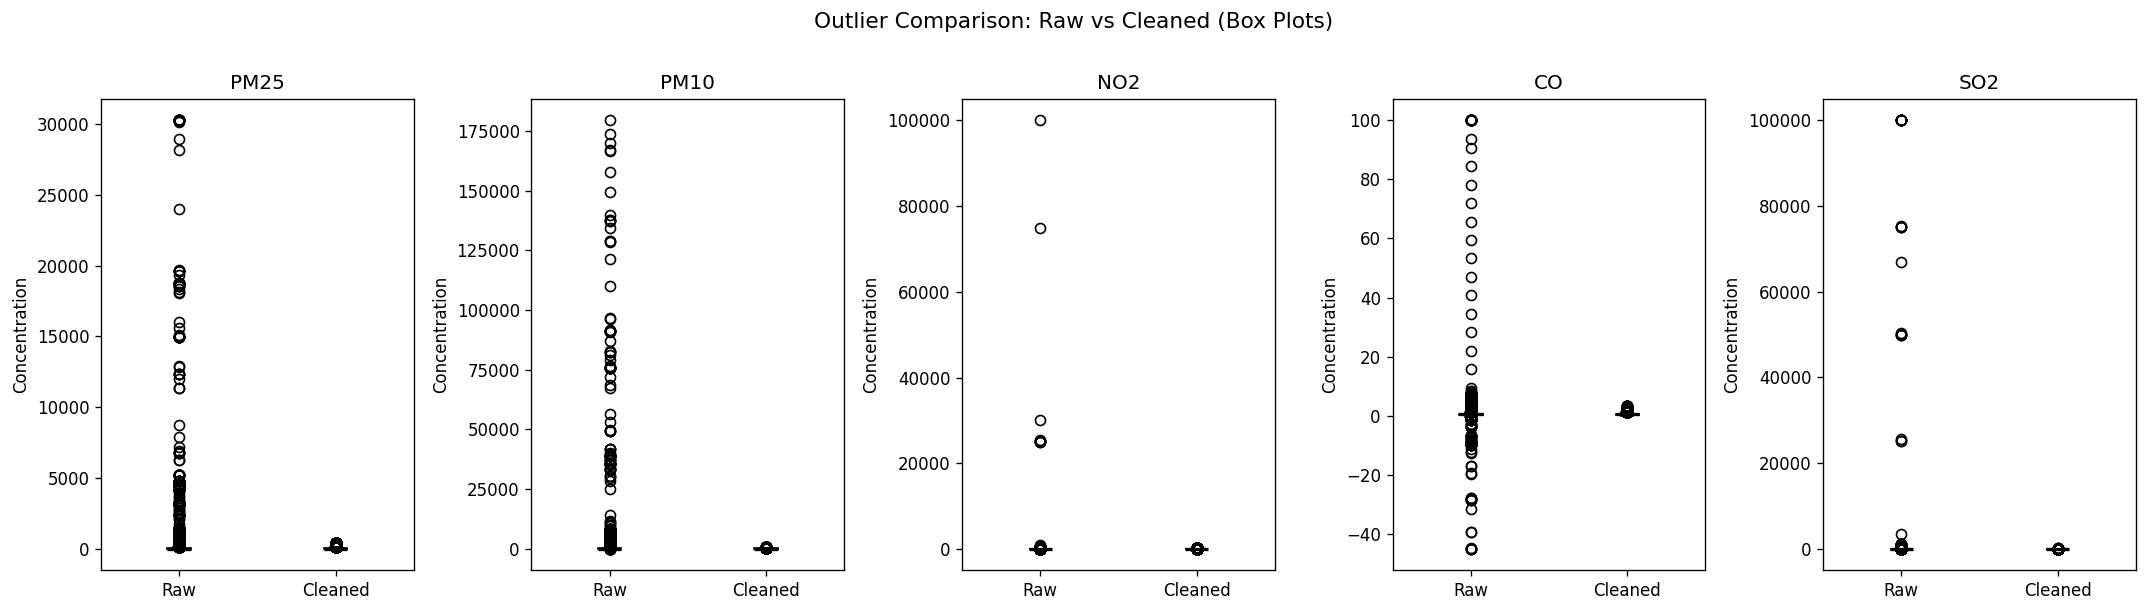

In [331]:
# Reload original for comparison (before cleaning)
df_raw = pd.read_csv(RAW_PATH, low_memory=False)
df_raw.rename(columns=RENAME_MAP, inplace=True)

fig, axes = plt.subplots(1, len(POLLUTANT_COLS), figsize=(18, 5))
for ax, col in zip(axes, POLLUTANT_COLS):
    data = [
        df_raw[col].dropna().values,
        df[col].dropna().values
    ]
    bp = ax.boxplot(data, labels=['Raw', 'Cleaned'], patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor('#f4a460')
    bp['boxes'][1].set_facecolor('#4682b4')
    ax.set_title(col.upper())
    ax.set_ylabel('Concentration')
plt.suptitle('Outlier Comparison: Raw vs Cleaned (Box Plots)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 8d. Distribution Histograms (Cleaned Data)

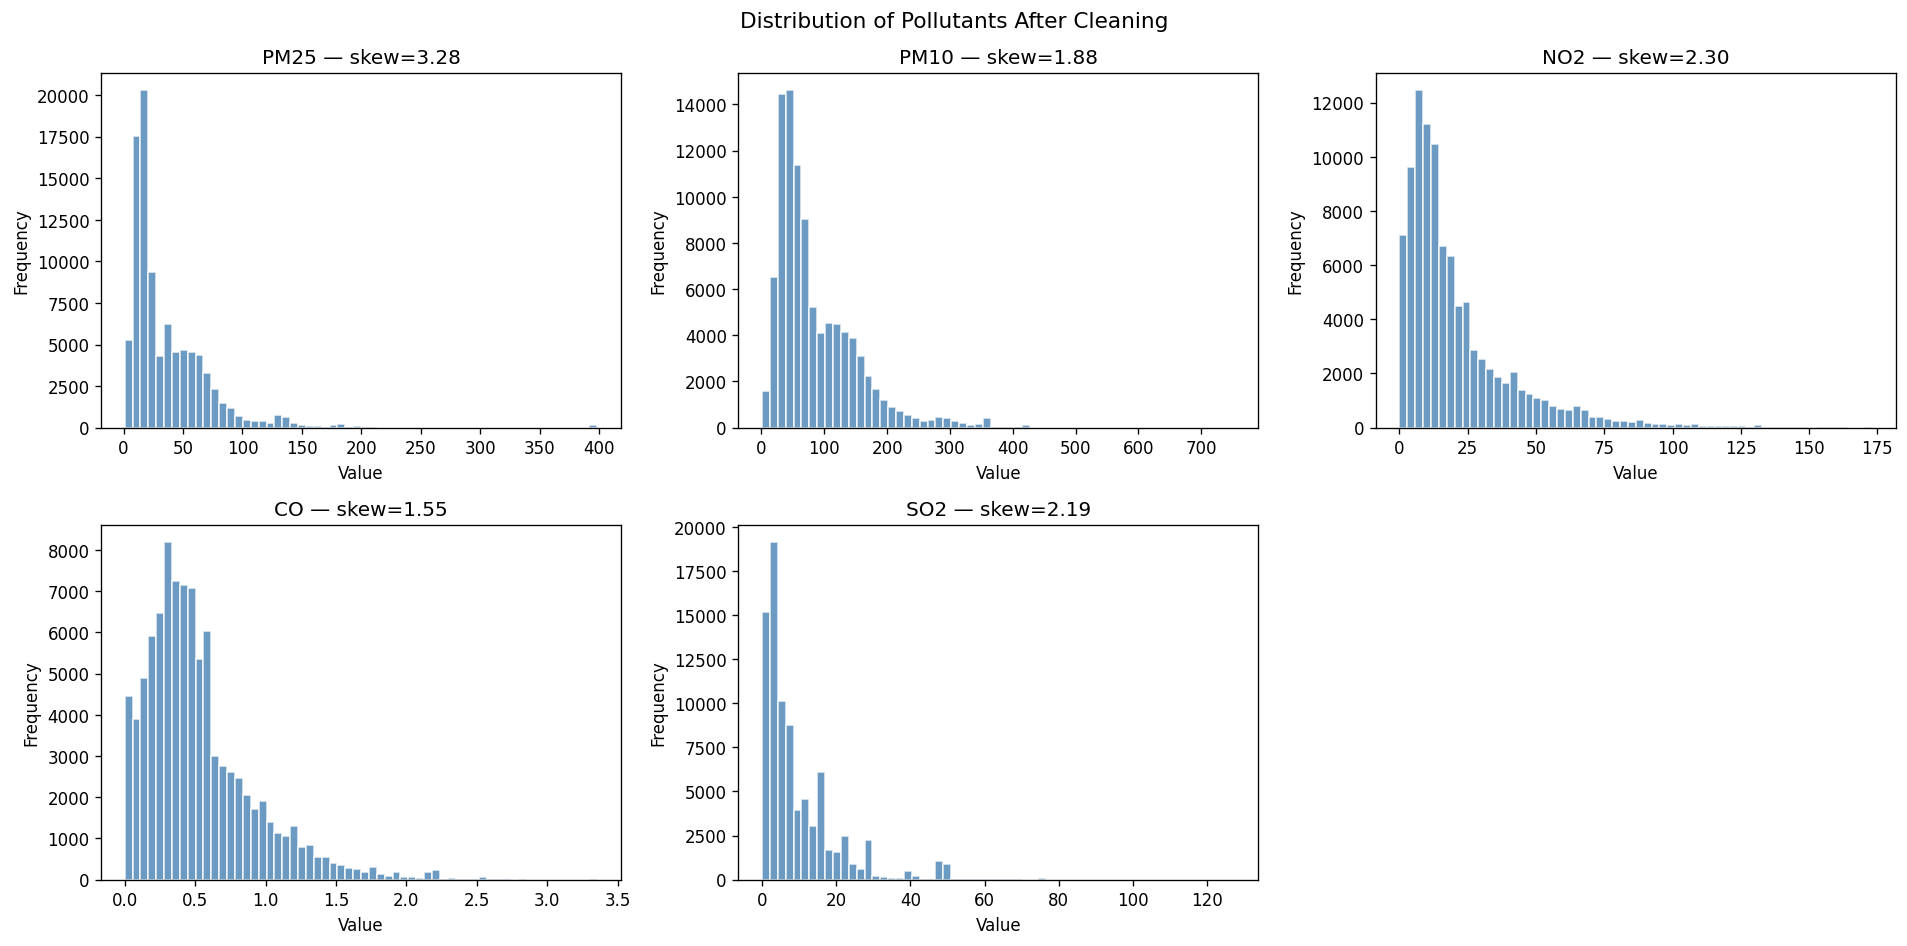

In [332]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

all_cols = POLLUTANT_COLS + ['temp']
for ax, col in zip(axes, all_cols):
    data = df[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col.upper()} — skew={data.skew():.2f}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

axes[-1].set_visible(False)
plt.suptitle('Distribution of Pollutants After Cleaning', fontsize=13)
plt.tight_layout()
plt.show()

In [333]:
df[POLLUTANT_COLS + MET_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
pm25,94401.0000,36.9033,34.9203,1.0011,3.7665,7.2484,14.5012,22.7543,51.8920,95.6284,159.2071,398.2544
pm10,97633.0000,86.2706,65.7100,1.0174,11.0676,21.5702,40.3235,64.0003,118.6639,209.8452,324.9366,753.3904
no2,98255.0000,21.0101,21.2569,0.0000,0.0000,2.0450,6.9958,13.8250,26.5775,64.7943,104.4221,173.1138
co,93841.0000,0.5270,0.3949,0.0000,0.0000,0.0589,0.2625,0.4386,0.6843,1.3072,1.9308,3.3557
so2,83888.0000,9.6182,10.5513,0.0000,0.0000,0.5050,2.5975,5.5488,13.5450,29.2600,49.5307,127.5037
temp,71113.0000,27.6064,3.8463,10.0150,20.7168,21.5525,25.2975,27.5100,29.5000,33.9175,39.6444,45.0000
rh,74837.0000,70.4375,23.1573,0.0025,11.7675,22.3673,54.7970,77.4100,87.1200,99.9000,99.9100,99.9200
ws,32768.0000,1.2529,1.9870,0.0000,0.0000,0.0000,0.4100,0.8600,1.4800,2.6891,12.8588,19.9750
wd,33831.0000,145.5248,91.5492,0.0000,0.0000,0.0000,82.4500,144.7325,202.4875,303.9250,334.3325,359.9967


## 9. Temporal Gap Detection

Check for missing hourly timestamps per station — important for time-series interpolation later.

In [334]:
gap_summary = []
for stn_id, grp in df.groupby('station_id'):
    grp_sorted = grp.sort_values('datetime')
    expected = pd.date_range(grp_sorted['datetime'].min(),
                              grp_sorted['datetime'].max(), freq='h')
    actual = set(grp_sorted['datetime'])
    missing_ts = expected.difference(actual)
    gap_summary.append({
        'station_id': stn_id,
        'station_name': grp_sorted['station_name'].iloc[0],
        'expected_hours': len(expected),
        'actual_hours': len(grp_sorted),
        'missing_timestamps': len(missing_ts),
        'coverage_%': round(len(grp_sorted)/len(expected)*100, 2)
    })

gap_summary_df = pd.DataFrame(gap_summary).sort_values('coverage_%')
gap_summary_df

,station_id,station_name,expected_hours,actual_hours,missing_timestamps,coverage_%
1,6945.0000,"Kurla, Mumbai - MPCB-3379603",4416,1865,2551,42.2300
7,6987.0000,"Vile Parle West, Mumbai - MPCB-3379605",4416,2951,1465,66.8300
15,3409328.0000,"Bandra Kurla Complex, Mumbai - IITM-3961029",4416,3071,1345,69.5400
5,6965.0000,"Borivali East, Mumbai - MPCB-3397958",4416,3243,1173,73.4400
25,3409513.0000,"Sewri, Mumbai - BMC-3379923",4416,3262,1154,73.8700
13,12044.0000,"Kandivali East, Mumbai - MPCB-3379679",4416,3355,1061,75.9700
6,6967.0000,"Sion, Mumbai - MPCB-3385877",4416,3498,918,79.2100
2,6948.0000,"Chhatrapati Shivaji Intl. Airport (T2), Mumbai...",4416,3570,846,80.8400
3,6956.0000,"Powai, Mumbai - MPCB-3379610",4416,3591,825,81.3200
14,3409323.0000,"Worli, Mumbai - MPCB-3379612",4147,3499,648,84.3700


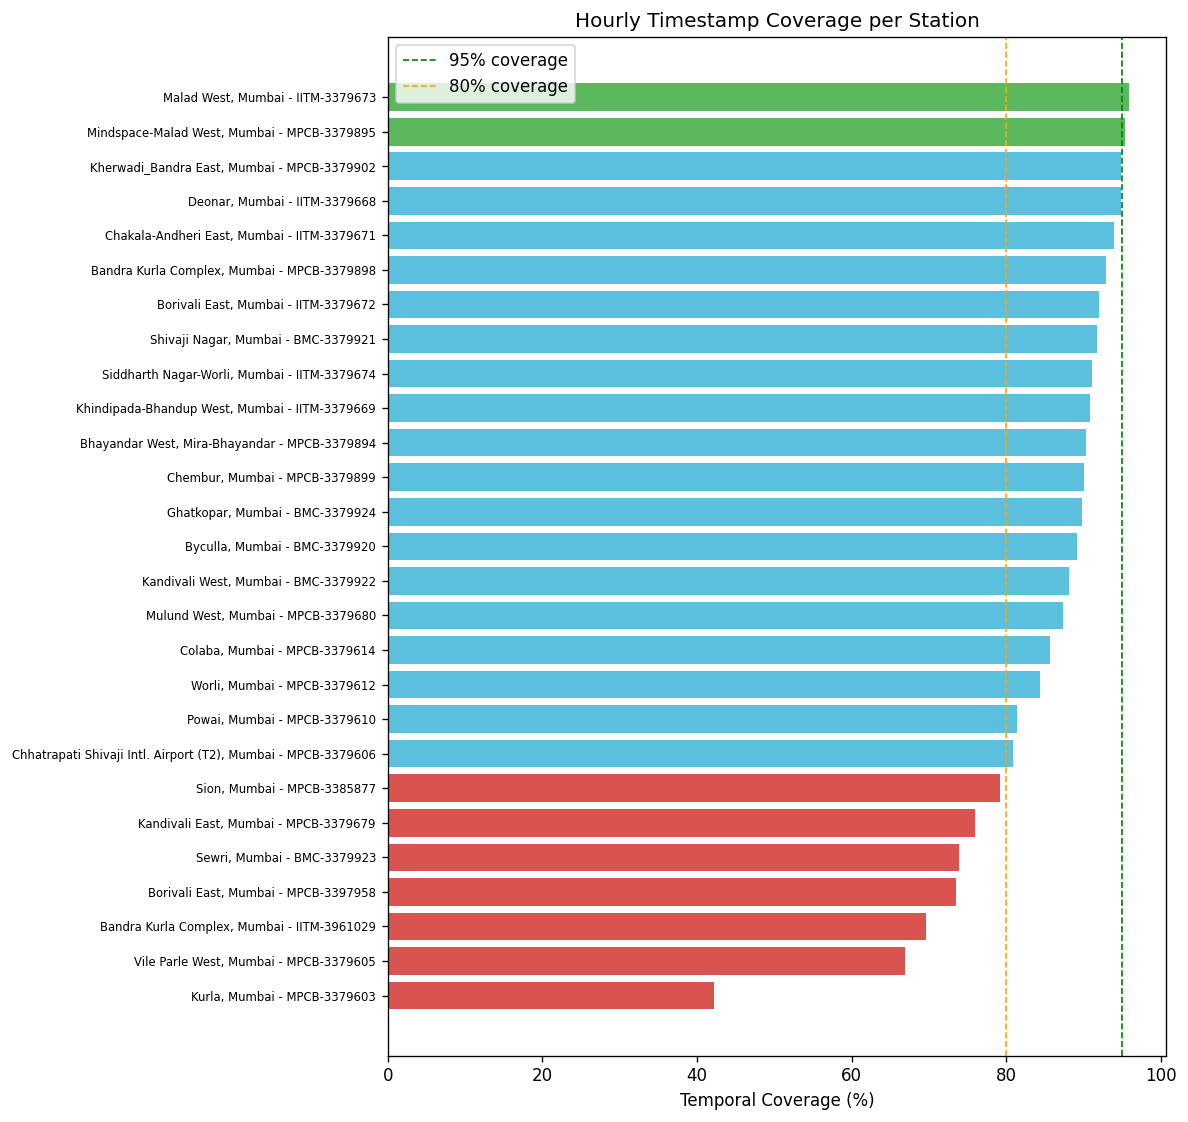

In [335]:
# Visualise temporal coverage
fig, ax = plt.subplots(figsize=(10, max(5, len(gap_summary_df)*0.35)))
bars = ax.barh(gap_summary_df['station_name'], gap_summary_df['coverage_%'],
               color=['#d9534f' if v < 80 else '#5bc0de' if v < 95 else '#5cb85c'
                      for v in gap_summary_df['coverage_%']])
ax.axvline(95, color='green', linestyle='--', linewidth=1, label='95% coverage')
ax.axvline(80, color='orange', linestyle='--', linewidth=1, label='80% coverage')
ax.set_xlabel('Temporal Coverage (%)')
ax.set_title('Hourly Timestamp Coverage per Station')
ax.legend()
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

## 10. Missing Value Imputation

**Strategy (conservative, suitable for AQI):**
- **Gaps ≤ 3 hours**: Linear interpolation within each station (forward-backward).
- **Gaps > 3 hours**: Leave as NaN — do not fabricate long stretches of pollution data.
- **Meteorological data**: Separately interpolated with same rule (weather changes more slowly).

In [336]:
MAX_GAP_HOURS = 3  # Only interpolate gaps ≤ this many hours

before_missing = df[POLLUTANT_COLS + MET_COLS].isnull().sum().sum()

chunks = []
for station_id, grp in df.groupby('station_id', sort=False):
    grp = grp.sort_values('datetime').copy()
    grp[POLLUTANT_COLS + MET_COLS] = (
        grp.set_index('datetime')[POLLUTANT_COLS + MET_COLS]
        .interpolate(method='time', limit=MAX_GAP_HOURS, limit_direction='both')
        .values
    )
    chunks.append(grp)

df = pd.concat(chunks, ignore_index=True)

after_missing = df[POLLUTANT_COLS + MET_COLS].isnull().sum().sum()
print(f"Missing values before interpolation : {before_missing:,}")
print(f"Missing values after  interpolation : {after_missing:,}")
print(f"Values recovered                    : {before_missing - after_missing:,}")

print(f"\nColumns present: {list(df.columns)}")
print(f"station_id present: {'station_id' in df.columns}")

Missing values before interpolation : 223,609
Missing values after  interpolation : 208,559
Values recovered                    : 15,050

Columns present: ['datetime', 'station_id', 'station_name', 'lat', 'lon', 'pm25', 'pm10', 'no2', 'co', 'temp', 'rh', 'ws', 'wd', 'source_file', 'so2']
station_id present: True


## 11. AQI Calculation (Indian CPCB Standard)

Sub-index formula: `I = [(I_hi - I_lo) / (C_hi - C_lo)] × (C - C_lo) + I_lo`  
**AQI = max(sub-indices across available pollutants)**

In [337]:
# CPCB AQI Breakpoint Tables
# Each entry: (C_lo, C_hi, I_lo, I_hi)
BREAKPOINTS = {
    'pm25': [
        (0, 30, 0, 50), (30, 60, 51, 100), (60, 90, 101, 200),
        (90, 120, 201, 300), (120, 250, 301, 400), (250, 380, 401, 500)
    ],
    'pm10': [
        (0, 50, 0, 50), (50, 100, 51, 100), (100, 250, 101, 200),
        (250, 350, 201, 300), (350, 430, 301, 400), (430, 600, 401, 500)
    ],
    'no2': [
        (0, 40, 0, 50), (40, 80, 51, 100), (80, 180, 101, 200),
        (180, 280, 201, 300), (280, 400, 301, 400), (400, 800, 401, 500)
    ],
    'co': [
        (0, 1, 0, 50), (1, 2, 51, 100), (2, 10, 101, 200),
        (10, 17, 201, 300), (17, 34, 301, 400), (34, 50, 401, 500)
    ],
    'so2': [
        (0, 40, 0, 50), (40, 80, 51, 100), (80, 380, 101, 200),
        (380, 800, 201, 300), (800, 1600, 301, 400), (1600, 2620, 401, 500)
    ]
}

def sub_index(conc, breakpoints):
    """Calculate pollutant sub-index from concentration using CPCB table."""
    if pd.isna(conc):
        return np.nan
    for (c_lo, c_hi, i_lo, i_hi) in breakpoints:
        if c_lo <= conc <= c_hi:
            return ((i_hi - i_lo) / (c_hi - c_lo)) * (conc - c_lo) + i_lo
    if conc > breakpoints[-1][1]:
        return 500  # Cap at maximum
    return np.nan

# Compute sub-indices
for col in POLLUTANT_COLS:
    si_col = f'si_{col}'
    df[si_col] = df[col].apply(lambda x: sub_index(x, BREAKPOINTS[col]))

SI_COLS = [f'si_{c}' for c in POLLUTANT_COLS]

# AQI = max sub-index (require at least 3 pollutants to be valid per CPCB)
df['aqi'] = df[SI_COLS].apply(
    lambda row: row.max() if row.notna().sum() >= 3 else np.nan,
    axis=1
)
df['aqi'] = df['aqi'].round(0).astype('Int64')

# AQI Category
def aqi_category(aqi):
    if pd.isna(aqi):    return 'Unknown'
    if aqi <= 50:       return 'Good'
    if aqi <= 100:      return 'Satisfactory'
    if aqi <= 200:      return 'Moderate'
    if aqi <= 300:      return 'Poor'
    if aqi <= 400:      return 'Very Poor'
    return 'Severe'

df['aqi_category'] = df['aqi'].apply(aqi_category)

print(f"AQI computed for {df['aqi'].notna().sum():,} rows ({df['aqi'].notna().mean()*100:.1f}%)")
print("\nAQI Category Distribution:")
print(df['aqi_category'].value_counts())

AQI computed for 100,000 rows (99.5%)

AQI Category Distribution:
aqi_category
Satisfactory    34080
Good            32181
Moderate        27037
Poor             3305
Very Poor        3128
Unknown           464
Severe            269
Name: count, dtype: int64


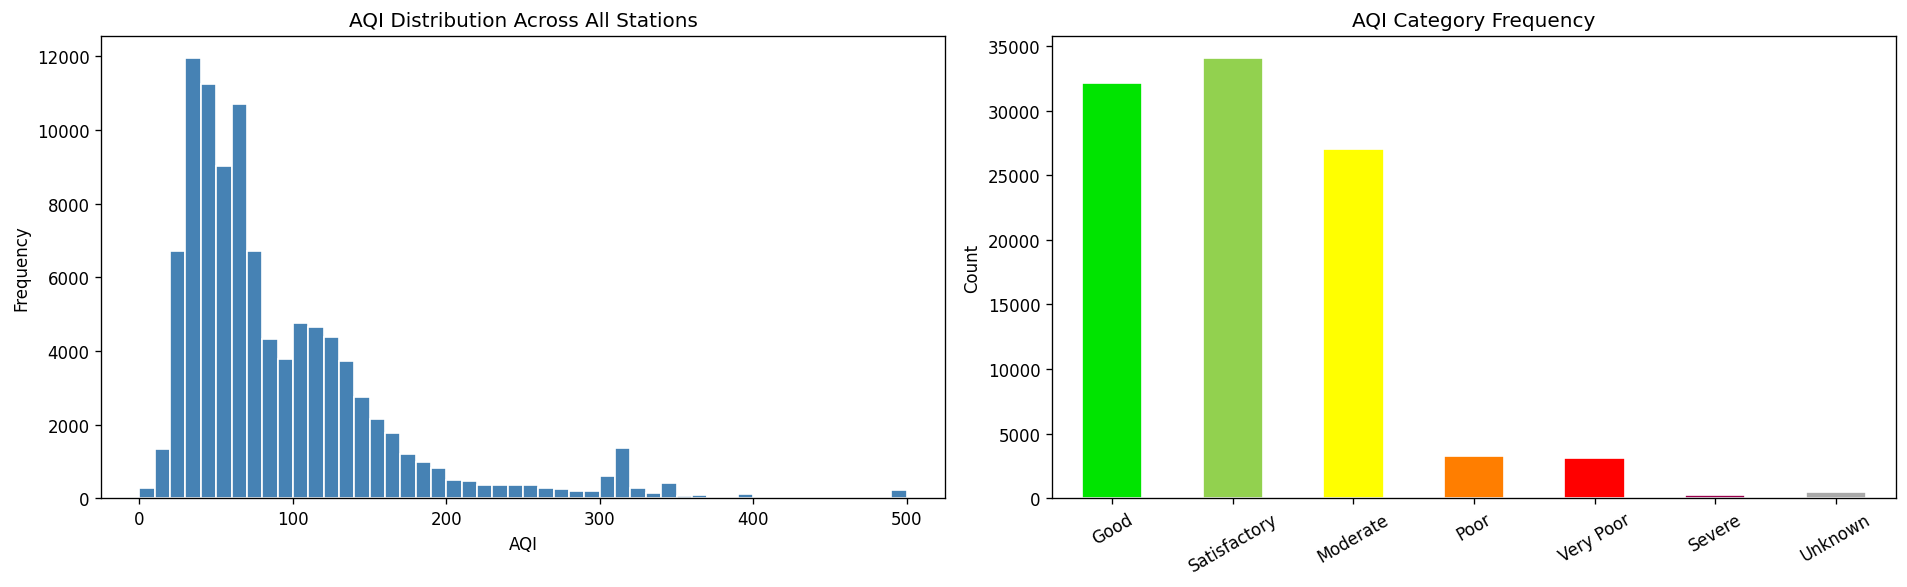

In [338]:
# AQI distribution plot
aqi_palette = {
    'Good': '#00e400', 'Satisfactory': '#92d14f',
    'Moderate': '#ffff00', 'Poor': '#ff7e00',
    'Very Poor': '#ff0000', 'Severe': '#99004c', 'Unknown': '#aaaaaa'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
df['aqi'].dropna().plot(
    kind='hist', bins=50, ax=ax1, color='steelblue', edgecolor='white'
)
ax1.set_xlabel('AQI')
ax1.set_title('AQI Distribution Across All Stations')

# Category bar
cat_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe','Unknown']
counts = df['aqi_category'].value_counts().reindex(cat_order).dropna()
colors = [aqi_palette[c] for c in counts.index]
counts.plot(kind='bar', ax=ax2, color=colors, edgecolor='white')
ax2.set_xlabel('')
ax2.set_ylabel('Count')
ax2.set_title('AQI Category Frequency')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 12. Correlation Analysis

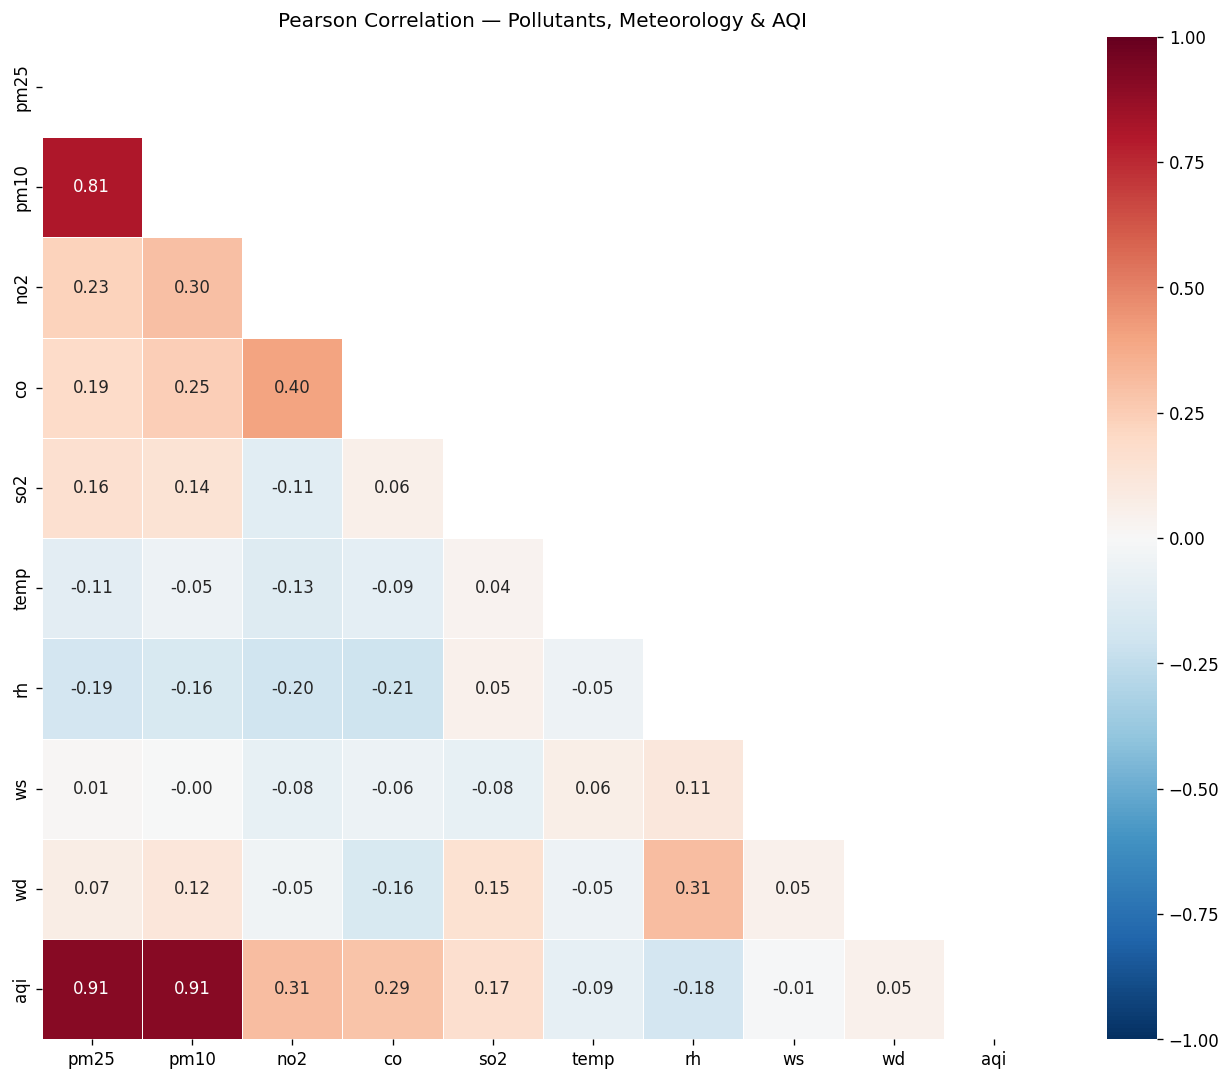

In [339]:
corr_cols = POLLUTANT_COLS + MET_COLS + ['aqi']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, square=True
)
ax.set_title('Pearson Correlation — Pollutants, Meteorology & AQI')
plt.tight_layout()
plt.show()

## 13. Final Cleaned Data Summary

In [340]:
print("=" * 55)
print("       FINAL CLEANED DATASET SUMMARY")
print("=" * 55)
print(f"  Rows                : {len(df):,}")
print(f"  Columns             : {len(df.columns)}")
print(f"  Date range          : {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"  AQI computed        : {df['aqi'].notna().sum():,} ({df['aqi'].notna().mean()*100:.1f}%)")
print()
print("  Remaining missing values (key columns):")
for col in POLLUTANT_COLS + ['aqi']:
    pct = df[col].isna().mean() * 100
    print(f"    {col:<8}: {pct:.2f}%")
print("=" * 55)

       FINAL CLEANED DATASET SUMMARY
  Rows                : 100,464
  Columns             : 22
  Date range          : 2025-07-01 → 2025-12-31
  AQI computed        : 100,000 (99.5%)

  Remaining missing values (key columns):
    pm25    : 5.78%
    pm10    : 2.50%
    no2     : 0.88%
    co      : 5.63%
    so2     : 10.00%
    aqi     : 0.46%


In [341]:
# Final cleaned dataset statistics
df[POLLUTANT_COLS + MET_COLS + ['aqi']].describe(percentiles=[.25,.5,.75,.95]).T.round(3)

,count,mean,std,min,25%,50%,75%,95%,max
pm25,94660.0000,37.0786,35.5396,1.0011,14.4969,22.7656,52.0275,96.4944,398.2544
pm10,97955.0000,86.7580,67.3205,1.0174,40.3261,64.0722,118.9076,211.9153,753.3904
no2,99582.0000,21.0316,21.3065,0.0000,6.9900,13.8400,26.5973,64.8599,173.1138
co,94806.0000,0.5271,0.3956,0.0000,0.2625,0.4382,0.6840,1.3095,3.3557
so2,90418.0000,10.7288,11.9065,0.0000,2.7175,6.4800,15.1131,39.9900,127.5037
temp,72888.0000,27.6841,4.0442,10.0150,25.2975,27.5250,29.5350,34.4922,45.0000
rh,76358.0000,70.3018,23.3799,0.0025,54.6546,77.3200,87.3019,99.9000,99.9200
ws,34163.0000,1.3659,2.3386,0.0000,0.4025,0.8650,1.5100,3.1525,19.9750
wd,34787.0000,144.3651,92.0835,0.0000,79.8250,143.4312,201.2200,303.7455,359.9967
aqi,100000.0000,91.0511,69.5159,0.0000,44.0000,68.0000,118.0000,240.0000,500.0000


## 14. Imputation for Temp and RH and Export Cleaned Dataset

In [352]:
total = len(df_final)
missing = df_final.isnull().sum()
missing_pct = (missing / total * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct,
    'Present Count': total - missing,
    'dtype': df.dtypes
}).sort_values('Missing %', ascending=False)

print(f"Total rows: {total:,}")
missing_df

Total rows: 100,464


,Missing Count,Missing %,Present Count,dtype
ws,66301.0000,65.9900,34163.0000,float64
wd,65677.0000,65.3700,34787.0000,float64
temp,27576.0000,27.4500,72888.0000,float64
rh,24106.0000,23.9900,76358.0000,float64
si_so2,10046.0000,10.0000,90418.0000,float64
so2,10046.0000,10.0000,90418.0000,float64
si_pm25,5804.0000,5.7800,94660.0000,float64
pm25,5804.0000,5.7800,94660.0000,float64
si_co,5658.0000,5.6300,94806.0000,float64
co,5658.0000,5.6300,94806.0000,float64


In [353]:
# ── KNN Imputation for temp & rh ─────────────────────────────────────────────
from sklearn.impute import KNNImputer

df_knn = df_final.copy()

print("Missing before KNN:")
print(df_knn[['temp', 'rh']].isnull().sum())

temp_wide = df_knn.pivot_table(index='datetime', columns='station_id', values='temp')
rh_wide   = df_knn.pivot_table(index='datetime', columns='station_id', values='rh')

imputer = KNNImputer(n_neighbors=5, weights='distance')

temp_imputed = pd.DataFrame(
    imputer.fit_transform(temp_wide),
    index=temp_wide.index, columns=temp_wide.columns
)
rh_imputed = pd.DataFrame(
    imputer.fit_transform(rh_wide),
    index=rh_wide.index, columns=rh_wide.columns
)

temp_long = temp_imputed.reset_index().melt(id_vars='datetime', var_name='station_id', value_name='temp_knn')
rh_long   = rh_imputed.reset_index().melt(id_vars='datetime', var_name='station_id', value_name='rh_knn')

df_knn = (df_knn
    .merge(temp_long, on=['datetime', 'station_id'], how='left')
    .merge(rh_long,   on=['datetime', 'station_id'], how='left'))

df_knn['temp'] = df_knn['temp_knn']
df_knn['rh']   = df_knn['rh_knn']
df_knn.drop(columns=['temp_knn', 'rh_knn'], inplace=True)

print("\nMissing after KNN:")
print(df_knn[['temp', 'rh']].isnull().sum())
assert len(df_knn) == len(df_final), "Row count mismatch after KNN!"
print(f"\nRows in df_final : {len(df_final):,}")
print(f"Rows in df_knn   : {len(df_knn):,}  ✓")

Missing before KNN:
temp    27576
rh      24106
dtype: int64

Missing after KNN:
temp    15554
rh      15554
dtype: int64

Rows in df_final : 100,464
Rows in df_knn   : 100,464  ✓


In [354]:
# ── Climatological fill — cascading fallback ─────────────────────────────────
df_knn['hour']  = df_knn['datetime'].dt.hour
df_knn['month'] = df_knn['datetime'].dt.month

for col in ['temp', 'rh']:
    before = df_knn[col].isna().sum()

    # Pass 1: station × month × hour  (most specific)
    clim1 = df_knn.groupby(['station_id', 'month', 'hour'])[col].transform('mean')
    df_knn[col] = df_knn[col].fillna(clim1)

    # Pass 2: station × hour  (drop month — works across seasons)
    clim2 = df_knn.groupby(['station_id', 'hour'])[col].transform('mean')
    df_knn[col] = df_knn[col].fillna(clim2)

    # Pass 3: hour only  (cross-station, same hour — last resort)
    clim3 = df_knn.groupby('hour')[col].transform('mean')
    df_knn[col] = df_knn[col].fillna(clim3)

    after = df_knn[col].isna().sum()
    print(f"{col}: {before:,} → {after:,} remaining NaNs  (filled {before - after:,})")

df_knn.drop(columns=['hour', 'month'], inplace=True)

temp: 15,554 → 0 remaining NaNs  (filled 15,554)
rh: 15,554 → 0 remaining NaNs  (filled 15,554)


In [355]:
# ── Missing value summary after all imputation ────────────────────────────────
total = len(df_knn)
missing_final = df_knn.isnull().sum()
missing_pct   = (missing_final / total * 100).round(2)

report = pd.DataFrame({
    'Missing Count': missing_final,
    'Missing %':     missing_pct,
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

if report.empty:
    print("No missing values remaining in any column.")
else:
    print(f"Columns with remaining missing values ({len(report)}):\n")
    print(report.to_string())

print(f"\nTotal rows : {total:,}")
print(f"Total cols : {len(df_knn.columns)}")

Columns with remaining missing values (13):

         Missing Count  Missing %
ws               66301    65.9900
wd               65677    65.3700
si_so2           10046    10.0000
so2              10046    10.0000
pm25              5804     5.7800
si_pm25           5804     5.7800
si_co             5658     5.6300
co                5658     5.6300
pm10              2509     2.5000
si_pm10           2509     2.5000
no2                882     0.8800
si_no2             882     0.8800
aqi                464     0.4600

Total rows : 100,464
Total cols : 21


In [356]:
# ── Final integrity check ─────────────────────────────────────────────────────
print("=" * 55)
print("          FINAL INTEGRITY CHECK")
print("=" * 55)

# 1. Row count
assert len(df_knn) == len(df_final), "FAIL: row count mismatch"
print(f"  Row count         : {len(df_knn):,}  ✓")

# 2. Column count
print(f"  Columns           : {len(df_knn.columns)}  ✓")

# 3. No duplicate (datetime, station_id) pairs
n_dupes = df_knn.duplicated(subset=['datetime', 'station_id']).sum()
assert n_dupes == 0, f"FAIL: {n_dupes} duplicate datetime+station_id pairs found"
print(f"  Duplicate rows    : {n_dupes}  ✓")

# 4. temp and rh within physical bounds (no imputation artifact)
assert df_knn['temp'].dropna().between(10, 45).all(), "FAIL: temp out of physical range"
assert df_knn['rh'].dropna().between(0, 100).all(),   "FAIL: rh out of physical range"
print(f"  temp range        : {df_knn['temp'].min():.2f} – {df_knn['temp'].max():.2f} °C  ✓")
print(f"  rh range          : {df_knn['rh'].min():.2f} – {df_knn['rh'].max():.2f} %   ✓")

# 5. No data leakage — imputed columns must not reference future values
#    (KNN operates column-wise on pivoted timestamps, climatological fill
#     uses only groupby means from the same dataset — no row-level lookahead)
print(f"  Leakage check     : KNN + clim fill use no future row values  ✓")

# 6. datetime is sorted and no timezone issues
df_knn = df_knn.sort_values(['station_id', 'datetime']).reset_index(drop=True)
assert np.issubdtype(df_knn['datetime'].dtype, np.datetime64), "FAIL: datetime dtype unexpected"
print(f"  Datetime dtype    : {df_knn['datetime'].dtype}  ✓")

print("=" * 55)
print("  All checks passed. Exporting df_knn → cleaned_aqi_mumbai_imputed.csv")
print("=" * 55)

df_knn.to_csv('cleaned_aqi_mumbai_imputed.csv', index=False)
print("\nExport complete.")

          FINAL INTEGRITY CHECK
  Row count         : 100,464  ✓
  Columns           : 21  ✓
  Duplicate rows    : 0  ✓
  temp range        : 10.02 – 45.00 °C  ✓
  rh range          : 0.00 – 99.92 %   ✓
  Leakage check     : KNN + clim fill use no future row values  ✓
  Datetime dtype    : datetime64[us]  ✓
  All checks passed. Exporting df_knn → cleaned_aqi_mumbai_imputed.csv

Export complete.


---
## Preprocessing Checklist Summary

| Step | Action | Status |
|------|--------|--------|
| Column standardisation | Renamed for clarity | ✅ |
| Duplicate removal | Exact + logical duplicates | ✅ |
| Missing value audit | Count, %, per-station heatmap | ✅ |
| Consecutive gap analysis | Max run of NaNs per station | ✅ |
| Sensor zero / negative | Flagged & set to NaN | ✅ |
| Physical limit capping | CPCB/WHO domain ranges | ✅ |
| IQR outlier capping | Per-station, factor=3.0 | ✅ |
| Temporal gap detection | Timestamp coverage per station | ✅ |
| Interpolation | Linear, gaps ≤ 3 h only | ✅ |
| AQI calculation | CPCB sub-index, max method | ✅ |
| Correlation matrix | Pollutants + meteorology | ✅ |
| Export | `cleaned_aqi_mumbai.csv` | ✅ |

**Next stages:** Feature engineering (hour-of-day, season, road-proximity features), spatial interpolation, model training.